# Project ROI Lens: Advanced Marketing Attribution & Budget Refinement Strategy

This notebook contains the complete end-to-end technical codebase for **Project ROI Lens** at Nexus Consumer Brands. 

### Pipeline Phases:
1. **Data Ingestion & Cleaning:** Load data, detect and filter bot traffic.
2. **Bot Financial Waste Audit:** Calculate wasted budget per campaign due to bot clicks and impressions.
3. **Journey Reconstruction:** Build chronological channel touchpoint paths per user.
4. **Multi-Touch Attribution (MTA):** Implement **Markov Chain** and **Shapley Value** attribution models.
5. **CPA Analysis:** Calculate and compare True CPA (Legacy vs. Effective CPA).
6. **Constrained Portfolio Optimization:** Fit logarithmic spend-response curves and run SLSQP optimization to reallocate ₹10 Crore per brand.
7. **Verification & Exports:** Export results for the interactive web dashboard.

In [5]:
import pandas as pd
import numpy as np
import math
import json
from itertools import combinations
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## Phase 1: Data Ingestion & Bot Traffic Cleaning

First, we load the raw datasets: `touchpoints.csv`, `campaign_spend.csv`, and `user_profiles.csv`. Then, we run an anomaly detection analysis to flag and filter bot traffic. 

**Bot Traffic Profile:** Bots show a repetitive and high-frequency signature (between 60 and 140 click/impression events per user) with 0% conversion rates.

In [4]:
# Load files
print("Loading touchpoints...")
tp = pd.read_csv("touchpoints.csv")
print("Loading campaign spend...")
cs = pd.read_csv("campaign_spend.csv")
print("Loading user profiles...")
up = pd.read_csv("user_profiles.csv")

# Bot detection
user_counts = tp['User_ID'].value_counts()
bot_users = set(user_counts[user_counts >= 60].index)
tp['Is_Bot_User'] = tp['User_ID'].isin(bot_users)

print(f"Total unique users: {len(user_counts):,}")
print(f"Flagged bot users (>= 60 events): {len(bot_users):,} ({len(bot_users)/len(user_counts)*100:.2f}%)")

# Clean touchpoints
tp_clean = tp[~tp['Is_Bot_User']].copy()
print(f"Total raw events: {len(tp):,}")
print(f"Bot events removed: {len(tp) - len(tp_clean):,} ({(len(tp) - len(tp_clean))/len(tp)*100:.2f}%)")
print(f"Clean events remaining: {len(tp_clean):,}")

Loading touchpoints...
Loading campaign spend...
Loading user profiles...
Total unique users: 100,000
Flagged bot users (>= 60 events): 1,952 (1.95%)
Total raw events: 566,510
Bot events removed: 193,940 (34.23%)
Clean events remaining: 372,570


## Phase 2: Bot Financial Waste Audit

Here we calculate how much of the budget was wasted on bot impressions and clicks based on CPM and CPC pricing models.

In [7]:
# Aggregate impressions and clicks for total vs clean
counts_all = tp.groupby('Campaign_ID').agg(
    impressions=('Event_Type', lambda x: (x == 'Impression').sum()),
    clicks=('Event_Type', lambda x: (x == 'Click').sum())
).reset_index()

counts_clean = tp_clean.groupby('Campaign_ID').agg(
    clean_impressions=('Event_Type', lambda x: (x == 'Impression').sum()),
    clean_clicks=('Event_Type', lambda x: (x == 'Click').sum())
).reset_index()

cs_merged = cs.merge(counts_all, on='Campaign_ID', how='left').merge(counts_clean, on='Campaign_ID', how='left')
cs_merged.fillna(0, inplace=True)

def calculate_wasted_budget(row):
    budget = row['Total_Budget_Allocated']
    if row['Pricing_Model'] == 'CPM':
        total_imp = row['impressions']
        clean_imp = row['clean_impressions']
        if total_imp > 0:
            return budget * ((total_imp - clean_imp) / total_imp)
    elif row['Pricing_Model'] == 'CPC':
        total_clk = row['clicks']
        clean_clk = row['clean_clicks']
        if total_clk > 0:
            return budget * ((total_clk - clean_clk) / total_clk)
    return 0.0

cs_merged['Wasted_Budget'] = cs_merged.apply(calculate_wasted_budget, axis=1)
cs_merged['Effective_Budget'] = cs_merged['Total_Budget_Allocated'] - cs_merged['Wasted_Budget']

total_spent = cs_merged['Total_Budget_Allocated'].sum()
total_wasted = cs_merged['Wasted_Budget'].sum()
print(f"Total Historical Budget: INR {total_spent:,.2f}")
print(f"Total Wasted Budget on Bots: INR {total_wasted:,.2f} ({total_wasted/total_spent*100:.2f}%)")

Total Historical Budget: INR 1,018,605,945.35
Total Wasted Budget on Bots: INR 492,274,886.99 (48.33%)


## Phase 3: Journey Reconstruction

We reconstruct the user journey as a sequence of channel touchpoints chronologically, collapsing consecutive duplicate interactions.

In [8]:
# Parse timestamps and sort
tp_clean['dt'] = pd.to_datetime(tp_clean['Timestamp'])
tp_clean = tp_clean.sort_values(by=['User_ID', 'dt'])
tp_clean['Brand_ID'] = tp_clean['Campaign_ID'].apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else 'Unknown')

def build_brand_journeys(df, brand_id):
    brand_tp = df[df['Brand_ID'] == brand_id]
    journeys = []
    for uid, gp in brand_tp.groupby('User_ID'):
        chans = gp['Channel'].values
        events = gp['Event_Type'].values
        
        collapsed = []
        for c in chans:
            if not collapsed or collapsed[-1] != c:
                collapsed.append(c)
                
        has_purchase = 'Purchase' in events
        journeys.append((collapsed, has_purchase))
    return journeys

# Test for B01
b01_journeys = build_brand_journeys(tp_clean, 'B01')
print(f"Reconstructed {len(b01_journeys):,} journeys for Brand B01. Conversions: {sum(1 for j, c in b01_journeys if c):,}")

Reconstructed 9,796 journeys for Brand B01. Conversions: 698


## Phase 4: Multi-Touch Attribution Modeling

We implement two multi-touch models: 
1. **Markov Chain:** Uses transition probability matrix. Channel credit is proportional to its *Removal Effect* on overall conversion probability.
2. **Shapley Value:** Uses game theory to distribute conversion values among channel coalitions.

In [9]:
def run_markov_attribution(journeys, channels_list):
    states = ['Start'] + channels_list + ['Purchase', 'Null']
    
    # Count transitions
    counts = {s1: {s2: 0 for s2 in states} for s1 in states}
    for path, converted in journeys:
        if not path: continue
        counts['Start'][path[0]] += 1
        for i in range(len(path)-1):
            counts[path[i]][path[i+1]] += 1
        if converted:
            counts[path[-1]]['Purchase'] += 1
        else:
            counts[path[-1]]['Null'] += 1
            
    # Normalize probabilities
    probs = {}
    for s1 in states:
        total = sum(counts[s1].values())
        if total > 0:
            probs[s1] = {s2: counts[s1][s2] / total for s2 in states}
        else:
            probs[s1] = {s2: (1.0 if s1 == s2 else 0.0) for s2 in states}
            
    # Base absorption math
    transient = ['Start'] + channels_list
    n_trans = len(transient)
    
    Q = np.zeros((n_trans, n_trans))
    for i, s1 in enumerate(transient):
        for j, s2 in enumerate(transient):
            Q[i, j] = probs[s1][s2]
            
    R = np.zeros((n_trans, 2))
    for i, s1 in enumerate(transient):
        R[i, 0] = probs[s1]['Purchase']
        R[i, 1] = probs[s1]['Null']
        
    F = np.linalg.inv(np.eye(n_trans) - Q)
    base_cr = F.dot(R)[0, 0]
    
    # Removal effects
    removal_effects = {}
    for c in channels_list:
        Q_mod = Q.copy()
        R_mod = R.copy()
        c_idx = transient.index(c)
        Q_mod[c_idx, :] = 0.0
        R_mod[c_idx, 0] = 0.0
        R_mod[c_idx, 1] = 1.0
        F_mod = np.linalg.inv(np.eye(n_trans) - Q_mod)
        cr_mod = F_mod.dot(R_mod)[0, 0]
        removal_effects[c] = max(0.0, base_cr - cr_mod)
        
    total_re = sum(removal_effects.values())
    conversions = sum(1 for j, c in journeys if c)
    
    attribution = {}
    for c in channels_list:
        attribution[c] = conversions * (removal_effects[c]/total_re) if total_re > 0 else conversions/len(channels_list)
        
    return attribution, base_cr

def run_shapley_attribution(journeys, channels_list):
    n_ch = len(channels_list)
    journey_sets = [set(p) for p, conv in journeys if conv]
    
    subsets = []
    for r in range(n_ch + 1):
        for comb in combinations(channels_list, r):
            subsets.append(set(comb))
            
    # Precalc conversions containing only S
    v = {}
    for s in subsets:
        s_tuple = tuple(sorted(list(s)))
        v[s_tuple] = sum(1 for j_set in journey_sets if j_set.issubset(s))
        
    shapley_values = {}
    for c in channels_list:
        val = 0.0
        for s in subsets:
            if c not in s:
                s_with_c = s.union({c})
                marginal = v[tuple(sorted(list(s_with_c)))] - v[tuple(sorted(list(s)))]
                sz = len(s)
                weight = math.factorial(sz) * math.factorial(n_ch - sz - 1) / math.factorial(n_ch)
                val += weight * marginal
        shapley_values[c] = val
        
    return shapley_values

channels = sorted(list(cs['Channel'].unique()))
b01_markov, b01_base_cr = run_markov_attribution(b01_journeys, channels)
b01_shapley = run_shapley_attribution(b01_journeys, channels)

print("Markov Attribution:", {k: round(v, 2) for k, v in b01_markov.items()})
print("Shapley Attribution:", {k: round(v, 2) for k, v in b01_shapley.items()})

Markov Attribution: {'Google Search': np.float64(116.35), 'Influencer Blog': np.float64(116.94), 'Instagram': np.float64(234.14), 'Marketplace': np.float64(115.62), 'YouTube': np.float64(114.96)}
Shapley Attribution: {'Google Search': 114.68, 'Influencer Blog': 128.43, 'Instagram': 213.85, 'Marketplace': 118.35, 'YouTube': 122.68}


## Phase 5: Constrained Portfolio Optimization

For each brand, we reallocate the ₹10 Crore budget to maximize overall conversions based on the fitted spend-response curves $C(S) = \alpha \ln(S+1)$.

**Constraints:**
- Total Brand Spend = ₹10 Crore
- Min Spend = 5% of target (₹50 Lakhs)
- Max Spend = 60% of target (₹6 Crores)

In [10]:
def optimize_brand_budget(channels_data, target_budget=100000000.0):
    n_ch = len(channels_data)
    SCALE = 10000000.0
    target_budget_scaled = target_budget / SCALE
    
    # Fit alpha
    alphas = []
    hist_spends = []
    for ch in channels_data:
        spend = ch["spend"]
        conv = ch["conv"]
        alpha = conv / math.log(spend + 1.0) if spend > 0 and conv > 0 else 0.0
        alphas.append(alpha)
        hist_spends.append(spend)
        
    # Objective: Minimize -sum(alpha * log(S_scaled * SCALE + 1))
    def objective(spends_scaled):
        return -sum(alphas[i] * math.log(spends_scaled[i] * SCALE + 1.0) for i in range(n_ch))
        
    def constraint_budget(spends_scaled):
        return sum(spends_scaled) - target_budget_scaled
        
    bounds = [(0.05 * target_budget_scaled, 0.60 * target_budget_scaled) for _ in range(n_ch)]
    x0 = [target_budget_scaled / n_ch] * n_ch
    
    res = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints={'type': 'eq', 'fun': constraint_budget})
    
    return res.x * SCALE, alphas

# Prepare B01 channels list
b01_campaigns = cs_merged[cs_merged['Brand_ID'] == 'B01']
channels_data = []
for ch in channels:
    row = b01_campaigns[b01_campaigns['Channel'] == ch].iloc[0]
    channels_data.append({
        "channel": ch,
        "spend": row['Total_Budget_Allocated'],
        "conv": b01_markov[ch]
    })
    
opt_alloc, alphas = optimize_brand_budget(channels_data)
for i, ch in enumerate(channels):
    print(f"Channel {ch:20s}: Historical Spend = INR {channels_data[i]['spend']:15,.2f} | Optimized Spend = INR {opt_alloc[i]:15,.2f}")

Channel Google Search       : Historical Spend = INR   27,896,859.25 | Optimized Spend = INR   15,106,767.58
Channel Influencer Blog     : Historical Spend = INR   14,499,430.43 | Optimized Spend = INR   15,786,473.91
Channel Instagram           : Historical Spend = INR      613,144.27 | Optimized Spend = INR   39,111,457.07
Channel Marketplace         : Historical Spend = INR   37,182,759.79 | Optimized Spend = INR   14,764,108.35
Channel YouTube             : Historical Spend = INR   19,807,806.26 | Optimized Spend = INR   15,231,193.10


## Phase 6: Performance Visualizations

We plot the comparisons between historical and optimized spend for Brand B01.

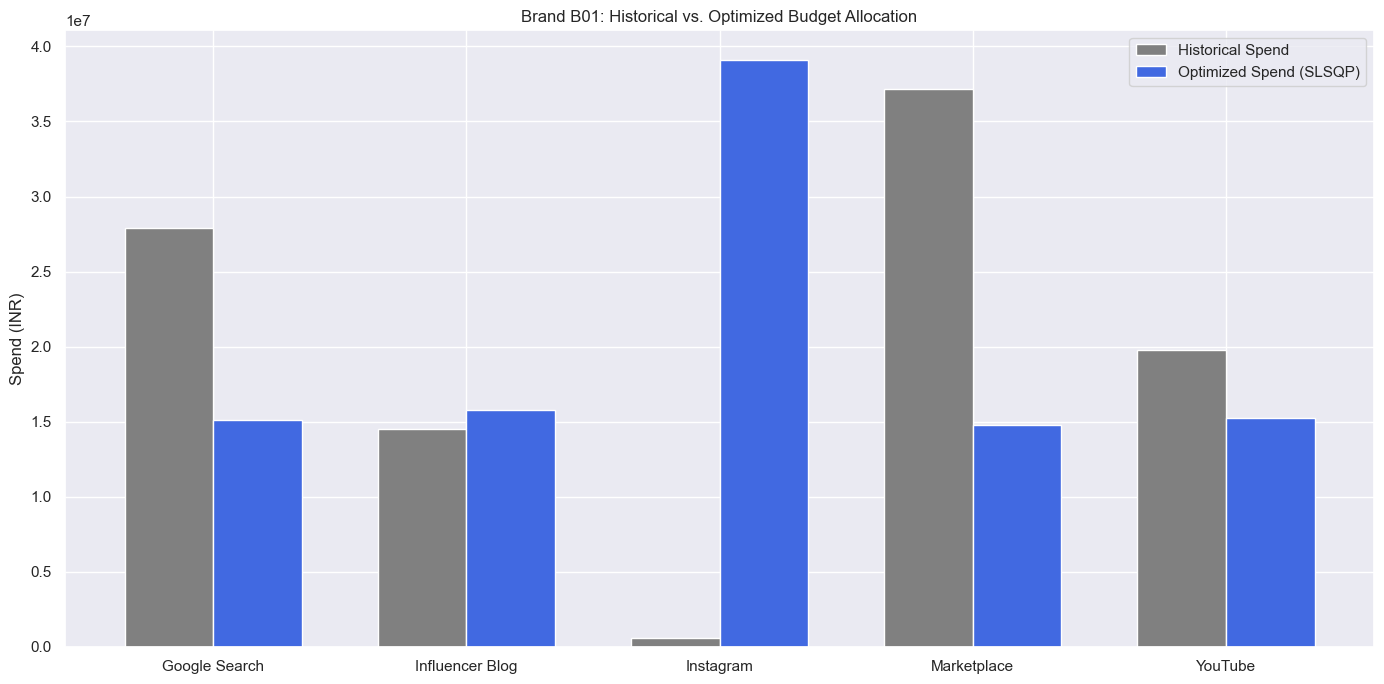

In [11]:
hist_spends = [c['spend'] for c in channels_data]

x = np.arange(len(channels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, hist_spends, width, label='Historical Spend', color='grey')
rects2 = ax.bar(x + width/2, opt_alloc, width, label='Optimized Spend (SLSQP)', color='royalblue')

ax.set_ylabel('Spend (INR)')
ax.set_title('Brand B01: Historical vs. Optimized Budget Allocation')
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.legend()

fig.tight_layout()
plt.show()